# LeR Advanced Sampling — Generating Detectable Events

This notebook is created by [Phurailatpam Hemantakumar](https://hemantaph.com)

[![Documentation](https://img.shields.io/badge/ler-documentation-blue)](https://ler.hemantaph.com) 

This notebook demonstrates how to generate a specific number of detectable events and monitor detection rate convergence as a function of sample size using the `LeR` class.

**Key Features:**
- Batch sampling until N detectable events are collected
- Rate convergence monitoring with stopping criteria
- Resume capability for interrupted sessions
- Visualization of rate convergence and parameter distributions

---

## Table of Contents

1. [Initialize LeR](#1-initialize-ler)
2. [Sampling N Detectable Events](#2-sampling-n-detectable-events)
   - [2.1 Unlensed Events](#2-1-unlensed-events)
   - [2.2 Rate Convergence (Unlensed)](#2-2-rate-convergence-unlensed)
   - [2.3 Rate Stability (Unlensed)](#2-3-rate-stability-unlensed)
   - [2.4 Lensed Events](#2-4-lensed-events)
   - [2.5 Rate Convergence (Lensed)](#2-5-rate-convergence-lensed)
   - [2.6 Rate Stability (Lensed)](#2-6-rate-stability-lensed)
   - [2.7 Rate Comparison](#2-7-rate-comparison)
3. [Parameter Distributions: All vs Detectable](#3-parameter-distributions-all-vs-detectable)
   - [3.1 Unlensed Events](#3-1-unlensed-events)
   - [3.2 Lensed Events](#3-2-lensed-events)
4. [Visualizing Lensed Detectable Events](#4-visualizing-lensed-detectable-events)
   - [4.1 Redshift Distribution](#4-1-redshift-distribution)
   - [4.2 Magnification Ratio vs Time Delay](#4-2-magnification-ratio-vs-time-delay)
   - [4.3 Caustic Plot](#4-3-caustic-plot)
5. [Summary](#summary)

---

## 1. Initialize LeR

The `LeR` class is the main interface for simulating unlensed and lensed GW events and calculating detection rates. Default settings:

- **Event type:** BBH (Binary Black Hole)
- **Lens model:** EPL+Shear (Elliptical Power Law with external shear)
- **Detectors:** H1, L1, V1 with O4 design sensitivity

Outputs are saved to `./ler_data` by default.

In [1]:
# Import LeR
from ler.rates import LeR

# Initialize LeR with default settings
# npool: number of parallel processes for sampling
# use this gwsnr's input args if you want SNR values in the output, besides the boolean detection probability values. This will increase the output dictionary size and the runtime of the code. For details, refer to https://gwsnr.hemantaph.com/examples/pdet_generation.html.:
# pdet_kwargs=dict(snr_th=10.0, snr_th_net=10.0, pdet_type="boolean", distribution_type="noncentral_chi2", include_optimal_snr=True, include_observed_snr=True)
ler = LeR(npool=6)

Extracting interpolator data from package to the current working directory.

Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh 

```python
# To print all initialization input arguments, use:
ler._print_all_init_args()
```

---

## 2. Sampling N Detectable Events

Sample GW events until a specified number of detectable events is collected and stopping criteria are met.

**Key features:**
- **Batch processing:** Events are sampled in batches for efficiency
- **Convergence monitoring:** Rate stability is tracked via stopping criteria
- **Resume capability:** Sampling can continue from previous sessions

### 2.1 Unlensed Events

Key parameters:
- `size`: Target number of detectable events
- `batch_size`: Events sampled per batch
- `stopping_criteria`: Convergence conditions
- `pdet_threshold`: Detection probability threshold
- `resume`: Resume from previous session

In [ ]:
# Sample until we have at least 10,000 detectable unlensed events with converged rates
# use 'print(ler.selecting_n_unlensed_detectable_events.__doc__)' to see all input args
detectable_rate_unlensed, unlensed_param_detectable_n = ler.selecting_n_unlensed_detectable_events(
    size=10000,                          # Target number of detectable events
    batch_size=100000,                   # Events per batch
    stopping_criteria=dict(
        relative_diff_percentage=0.1,    # Stop when rate change < 0.1%
        number_of_last_batches_to_check=4  # Check last 4 batches for convergence
    ),
    pdet_threshold=0.5,                  # Probability threshold for detection
    resume=True,                         # Resume from previous state if available
    output_jsonfile='unlensed_params_n_detectable.json',  # Output file for detectable events
    meta_data_file='meta_unlensed.json', # Store metadata (rates per batch)
    pdet_type='boolean',                 # Detection type: 'boolean' or 'float'
    trim_to_size=False,                  # Keep all events found until convergence
)

print(f"\n=== Unlensed N-Event Sampling Results ===")
print(f"Detectable event rate: {detectable_rate_unlensed:.4e} events per year")
print(f"Total detectable events collected: {len(unlensed_param_detectable_n['zs'])}")
# expected time: 12.9s

stopping criteria set to when relative difference of total rate for the last 4 cumulative batches is less than 0.1%.
sample collection will stop when the stopping criteria is met and number of detectable events exceeds the specified size.
data on output file ./ler_data/unlensed_params_n_detectable.json not found or corrupted. Starting from scratch.
removing ./ler_data/unlensed_params_n_detectable.json if it exists
removing ./ler_data/meta_unlensed.json if it exists
data on meta data file ./ler_data/meta_unlensed.json not found or corrupted. Starting from scratch.
removing ./ler_data/unlensed_params_n_detectable.json if it exists
removing ./ler_data/meta_unlensed.json if it exists
collected number of detectable events =  0
collected number of detectable events (batch) =  367
collected number of detectable events (cumulative) =  367
total number of events =  100000
total rate (yr^-1): 336.1125442971944
collected number of detectable events (batch) =  365
collected number of detectable ev

### 2.2 Rate Convergence (Unlensed)

Visualize how detection rate evolves with sample size. A converged rate indicates stable statistics.

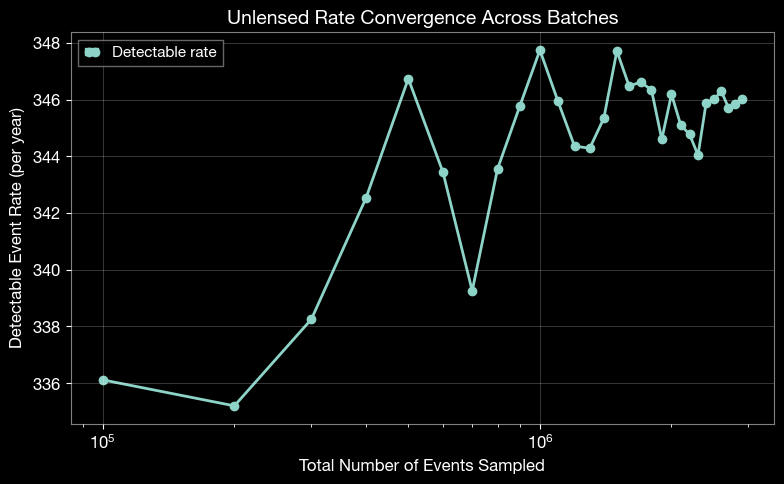

In [3]:
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json

# Load metadata containing rates for each batch
meta_data = get_param_from_json(ler.ler_directory + '/meta_unlensed.json')

# Plot rate vs sampling size
plt.figure(figsize=(8, 5))
plt.plot(
    meta_data['events_total'],
    meta_data['total_rate'],
    'o-',
    linewidth=2,
    markersize=6,
    color='C0',
    label='Detectable rate'
)

plt.xlabel('Total Number of Events Sampled', fontsize=12)
plt.ylabel('Detectable Event Rate (per year)', fontsize=12)
plt.title('Unlensed Rate Convergence Across Batches', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.xscale('log')
plt.tight_layout()
plt.show()

### 2.3 Rate Stability (Unlensed)

Quantify convergence using mean and standard deviation from the last few batches.

In [4]:
import numpy as np

# Select rates from the last 4 batches
idx_converged = [-4, -3, -2, -1]
rates_converged = np.array(meta_data['total_rate'])[idx_converged]

if len(rates_converged) > 0:
    mean_rate = rates_converged.mean()
    std_rate = rates_converged.std()
    
    print(f"=== Unlensed Rate Stability Analysis ===")
    print(f"Number of batches analyzed: {len(rates_converged)}")
    print(f"Mean rate: {mean_rate:.4e} events/year")
    print(f"Standard deviation: {std_rate:.4e} events/year")
    print(f"Relative uncertainty: {(std_rate/mean_rate)*100:.3f}%")
else:
    print("Not enough batches to assess convergence.")

# Update the rate with the converged mean
detectable_rate_unlensed = mean_rate

=== Unlensed Rate Stability Analysis ===
Number of batches analyzed: 4
Mean rate: 3.4597e+02 events/year
Standard deviation: 2.1574e-01 events/year
Relative uncertainty: 0.062%


### 2.4 Lensed Events

Generate lensed detectable events. For lensed events, we can specify:
- `pdet_threshold`: List of detection thresholds for each image
- `num_img`: Number of images that must meet each corresponding threshold

Here, `stopping_criteria=None` with `size=1000` means sampling continues until at least 1000 detectable lensed events are collected.

In [ ]:
# Sample until we have at least 1,000 detectable lensed events
# use 'print(ler.selecting_n_lensed_detectable_events.__doc__)' to see all input args
detectable_rate_lensed, lensed_param_detectable_n = ler.selecting_n_lensed_detectable_events(
    size=500,                           # Target number of detectable events
    batch_size=100000,                    # Events per batch
    stopping_criteria=None,              # No stopping criteria (sample until size is reached)
    pdet_threshold=[0.5, 0.5],           # Detection thresholds for images
    num_img=[1, 1],                      # Number of images required per threshold
    resume=True,                        # Resume from previous state if available
    output_jsonfile='lensed_params_n_detectable.json',
    meta_data_file='meta_lensed.json',
    pdet_type='boolean',
    trim_to_size=False,
)

print(f"\n=== Lensed N-Event Sampling Results ===")
print(f"Detectable event rate: {detectable_rate_lensed:.4e} events per year")
print(f"Total detectable events collected: {len(lensed_param_detectable_n['zs'])}")
# initial batch will take longer as it needs to compile the numba njit functions; expected time: ~50s in first batch, then ~15s per subsequent batch

stopping criteria not set. sample collection will stop when number of detectable events exceeds the specified size.
data on output file ./ler_data/lensed_params_n_detectable.json not found or corrupted. Starting from scratch.
removing ./ler_data/lensed_params_n_detectable.json if it exists
removing ./ler_data/meta_lensed.json if it exists
data on meta data file ./ler_data/meta_lensed.json not found or corrupted. Starting from scratch.
removing ./ler_data/lensed_params_n_detectable.json if it exists
removing ./ler_data/meta_lensed.json if it exists
collected number of detectable events =  0
collected number of detectable events (batch) =  64
collected number of detectable events (cumulative) =  64
total number of events =  50000
total rate (yr^-1): 0.1422831772378339
collected number of detectable events (batch) =  59
collected number of detectable events (cumulative) =  123
total number of events =  100000
total rate (yr^-1): 0.13672524062698102
collected number of detectable events (b

In [7]:
# include other useful parameters in the output dictionary.
# It is omitted by default to save runtime and memory.
# For theta_E, n_images, mass_1, mass_2, luminosity_distance:
lensed_param_detectable_n = ler.recover_redundant_parameters(lensed_param_detectable_n)
# For effective_luminosity_distance, effective_geocent_time, effective_phase, effective_ra, effective_dec:
lensed_param_detectable_n = ler.produce_effective_params(lensed_param_detectable_n)

# or you can simply set 'include_redundant_parameters=True, include_effective_parameters=True' in the input args of LeR initialization to include these parameters in the output dictionary by default.

### 2.5 Rate Convergence (Lensed)

Visualize the lensed detection rate evolution across batches.

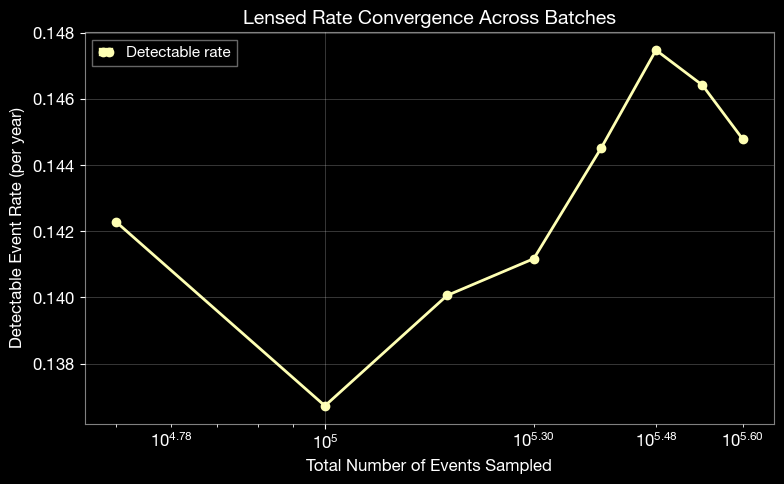

In [7]:
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json

# Load metadata containing rates for each batch
meta_data = get_param_from_json(ler.ler_directory + '/meta_lensed.json')

# Plot rate vs sampling size
plt.figure(figsize=(8, 5))
plt.plot(
    meta_data['events_total'],
    meta_data['total_rate'],
    'o-',
    linewidth=2,
    markersize=6,
    color='C1',
    label='Detectable rate'
)

plt.xlabel('Total Number of Events Sampled', fontsize=12)
plt.ylabel('Detectable Event Rate (per year)', fontsize=12)
plt.title('Lensed Rate Convergence Across Batches', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.xscale('log')
plt.tight_layout()
plt.show()

### 2.6 Rate Stability (Lensed)

Quantify convergence using mean and standard deviation from the last few batches.

In [8]:
import numpy as np

# Select rates from the last 4 batches
idx_converged = [-4, -3, -2, -1]
rates_converged = np.array(meta_data['total_rate'])[idx_converged]

if len(rates_converged) > 0:
    mean_rate = rates_converged.mean()
    std_rate = rates_converged.std()
    
    print(f"=== Lensed Rate Stability Analysis ===")
    print(f"Number of batches analyzed: {len(rates_converged)}")
    print(f"Mean rate: {mean_rate:.4e} events/year")
    print(f"Standard deviation: {std_rate:.4e} events/year")
    print(f"Relative uncertainty: {(std_rate/mean_rate)*100:.3f}%")
else:
    print("Not enough batches to assess convergence.")

# Update the rate with the converged mean
detectable_rate_lensed = mean_rate

=== Lensed Rate Stability Analysis ===
Number of batches analyzed: 4
Mean rate: 1.4579e-01 events/year
Standard deviation: 1.2114e-03 events/year
Relative uncertainty: 0.831%


### 2.7 Rate Comparison

Compare detection rates between lensed and unlensed events.

In [9]:
# Compare lensed vs unlensed rates
print(f"=== Detection Rate Comparison ===")
print(f"Unlensed detectable rate: {detectable_rate_unlensed:.4e} events/year")
print(f"Lensed detectable rate:   {detectable_rate_lensed:.4e} events/year")
print(f"Ratio (Unlensed/Lensed):  {(detectable_rate_unlensed/detectable_rate_lensed):.2f}")

=== Detection Rate Comparison ===
Unlensed detectable rate: 3.4597e+02 events/year
Lensed detectable rate:   1.4579e-01 events/year
Ratio (Unlensed/Lensed):  2373.04


---

## 3. Parameter Distributions: All vs Detectable

Compare parameter distributions between all sampled events and detectable events. Corner plots reveal **selection effects** introduced by detector sensitivity.

### 3.1 Unlensed Events

Generate a large sample of all unlensed events (both detectable and non-detectable) for comparison.

In [3]:
# Generate a large sample of all unlensed events for comparison
unlensed_param = ler.unlensed_cbc_statistics(size=50000, batch_size=50000, resume=True, output_jsonfile='unlensed_params_all.json')

print(f"Total unlensed events sampled: {len(unlensed_param['zs'])}")

unlensed params will be stored in ./ler_data/unlensed_params_all.json
resuming from ./ler_data/unlensed_params_all.json
unlensed parameters already sampled.
Total unlensed events sampled: 50000


Corner plot comparing all sampled events vs detectable events:

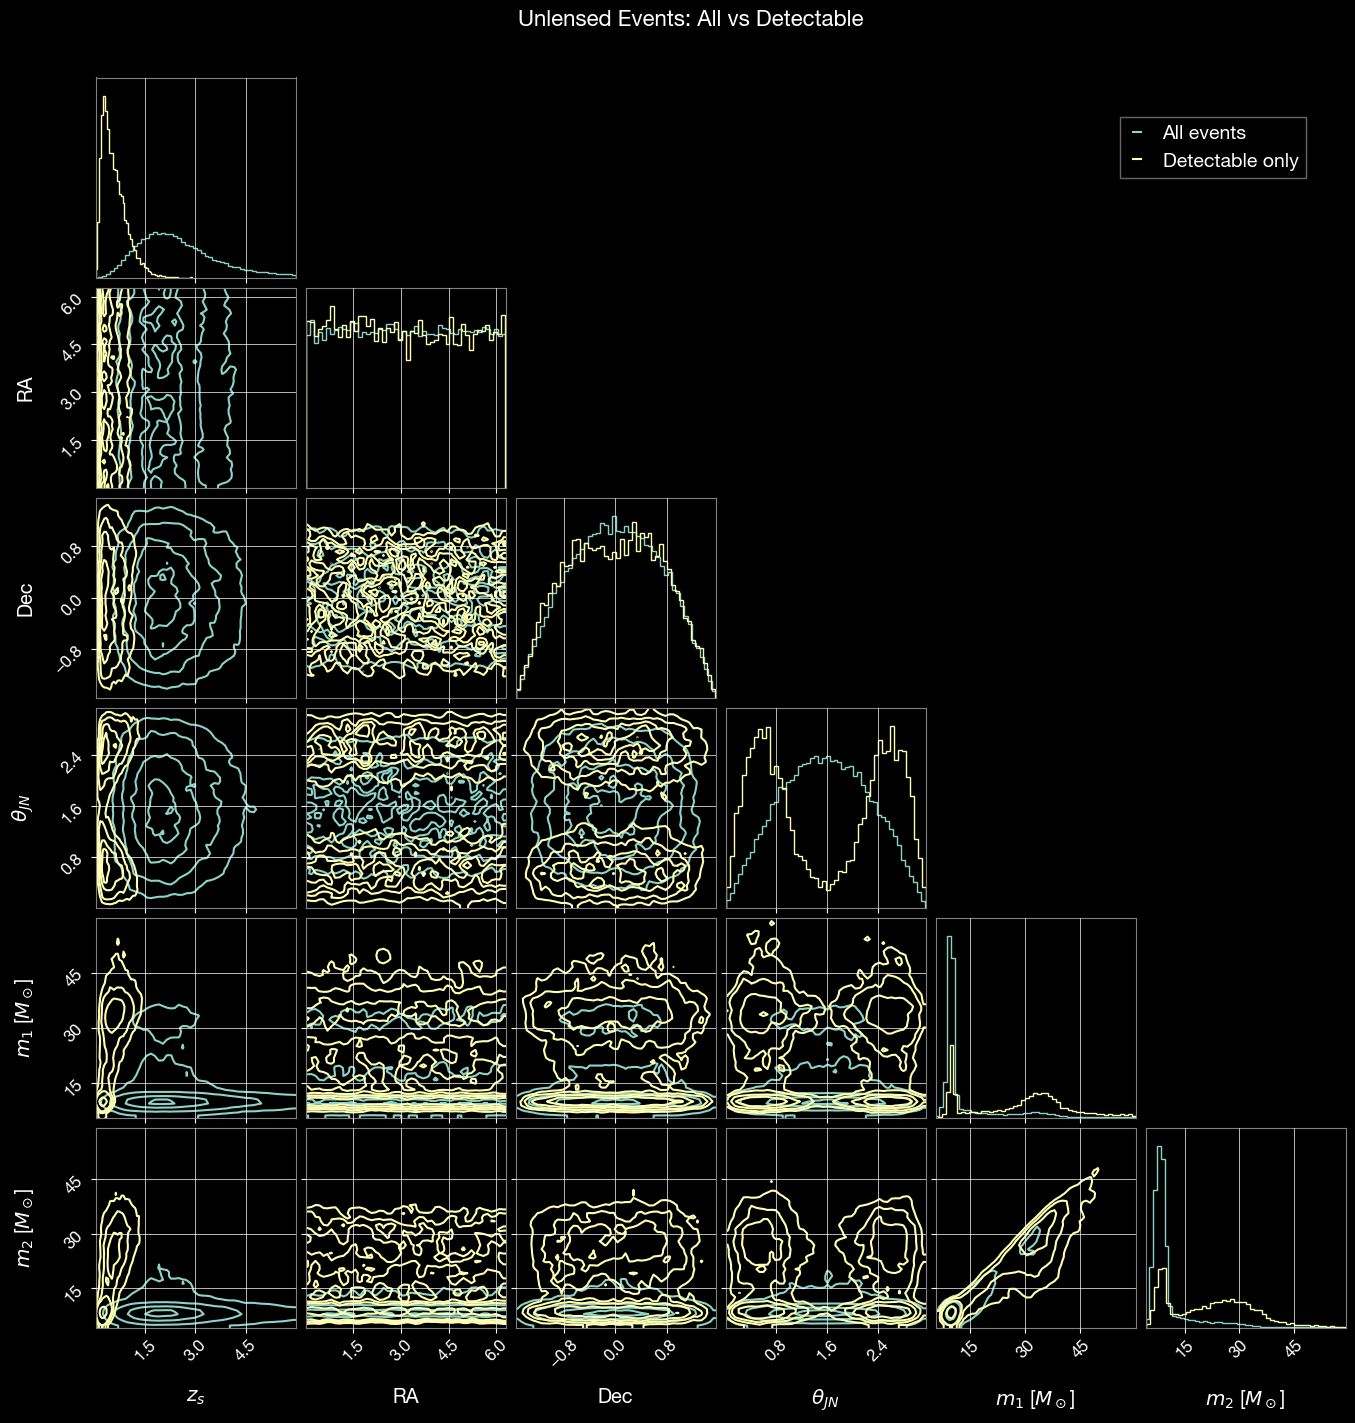

In [4]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from ler.utils import get_param_from_json

# Load data
param = get_param_from_json('./ler_data/unlensed_params_all.json')
param_detectable = get_param_from_json('./ler_data/unlensed_params_n_detectable.json')

# select mass_1_source less than 90 solar masses to focus on the more common stellar-mass black hole events
mask_all = (param['mass_1_source'] < 60) & (param['zs'] < 6.0)
mask_detectable = (param_detectable['mass_1_source'] < 60) & (param_detectable['zs'] < 6.0)

# Parameters to compare
param_names = ['zs', 'ra', 'dec', 'theta_jn', 'mass_1_source', 'mass_2_source']
labels = ['$z_s$', 'RA', 'Dec', r'$\theta_{JN}$', '$m_1$ [$M_\odot$]', '$m_2$ [$M_\odot$]']

# Prepare data for corner plot
samples_all = np.stack([param[p][mask_all] for p in param_names], axis=1)
samples_detectable = np.stack([param_detectable[p][mask_detectable] for p in param_names], axis=1)

# Create corner plot for all events
fig = corner.corner(
    samples_all, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    bins=50,
    hist_kwargs={'density': True}
)

# Overlay detectable events
corner.corner(
    samples_detectable, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig, 
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    bins=50,
    hist_kwargs={'density': True}
)

# Add legend
blue_line = mlines.Line2D([], [], color='C0', label='All events')
orange_line = mlines.Line2D([], [], color='C1', label='Detectable only')
fig.legend(handles=[blue_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
fig.suptitle('Unlensed Events: All vs Detectable', fontsize=16, y=1.02)

plt.show()

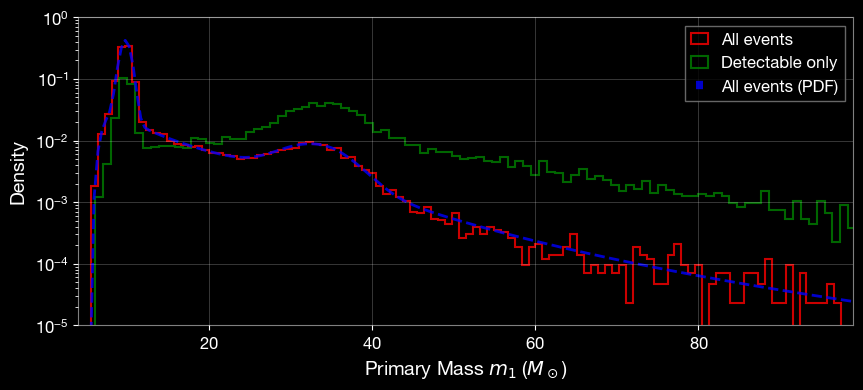

In [9]:
# plot param['mass_1_source']
plt.figure(figsize=(10, 4))
plt.hist(param['mass_1_source'], bins=300, alpha=0.8, linewidth=1.5, label='All events', density=True, histtype='step', color='r')
plt.hist(param_detectable['mass_1_source'], bins=300, alpha=0.8, linewidth=1.5, label='Detectable only', density=True, histtype='step', color='g')

mass_arr = np.linspace(4, 99, 200)
mass_pdf = ler.mass_1_source.pdf(mass_arr)
plt.plot(mass_arr, mass_pdf, 'b--', label='All events (PDF)', alpha=0.8, linewidth=2)

plt.xlabel('Primary Mass $m_1$ ($M_\\odot$)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.yscale('log')
plt.ylim(1e-5, 1.0)
plt.xlim(4, 99)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.2 Lensed Events

Compare intrinsic, strongly lensed, and detectable lensed event distributions. First, generate strongly lensed events:

In [ ]:
# Generate a large sample of all lensed events for comparison
lensed_param = ler.lensed_cbc_statistics(size=50000, batch_size=50000, resume=True, output_jsonfile='lensed_params_all.json')

print(f"Total lensed events sampled: {len(lensed_param['zs'])}")

lensed params will be stored in ./ler_data/lensed_params_all.json
removing ./ler_data/lensed_params_all.json if it exists
resuming from ./ler_data/lensed_params_all.json
Batch no. 1
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 149 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
calculating pdet...
saving all lensed parameters in ./ler_data/lensed_params_all.json 
Total lensed events sampled: 50000


Generate intrinsic parameters (without strong lensing selection):

In [11]:
# Generate a large sample of all lensed events for comparison
lensed_param_intrinsic = ler.sample_all_routine_epl_shear_intrinsic(size=50000)

print(f"Total lensed events sampled: {len(lensed_param_intrinsic['zs'])}")

# save to file
from ler.utils import append_json
append_json(ler.ler_directory+'/lensed_param_intrinsic.json', lensed_param_intrinsic, replace=True);

Total lensed events sampled: 50000


Corner plot comparing intrinsic, strongly lensed, and detectable events:

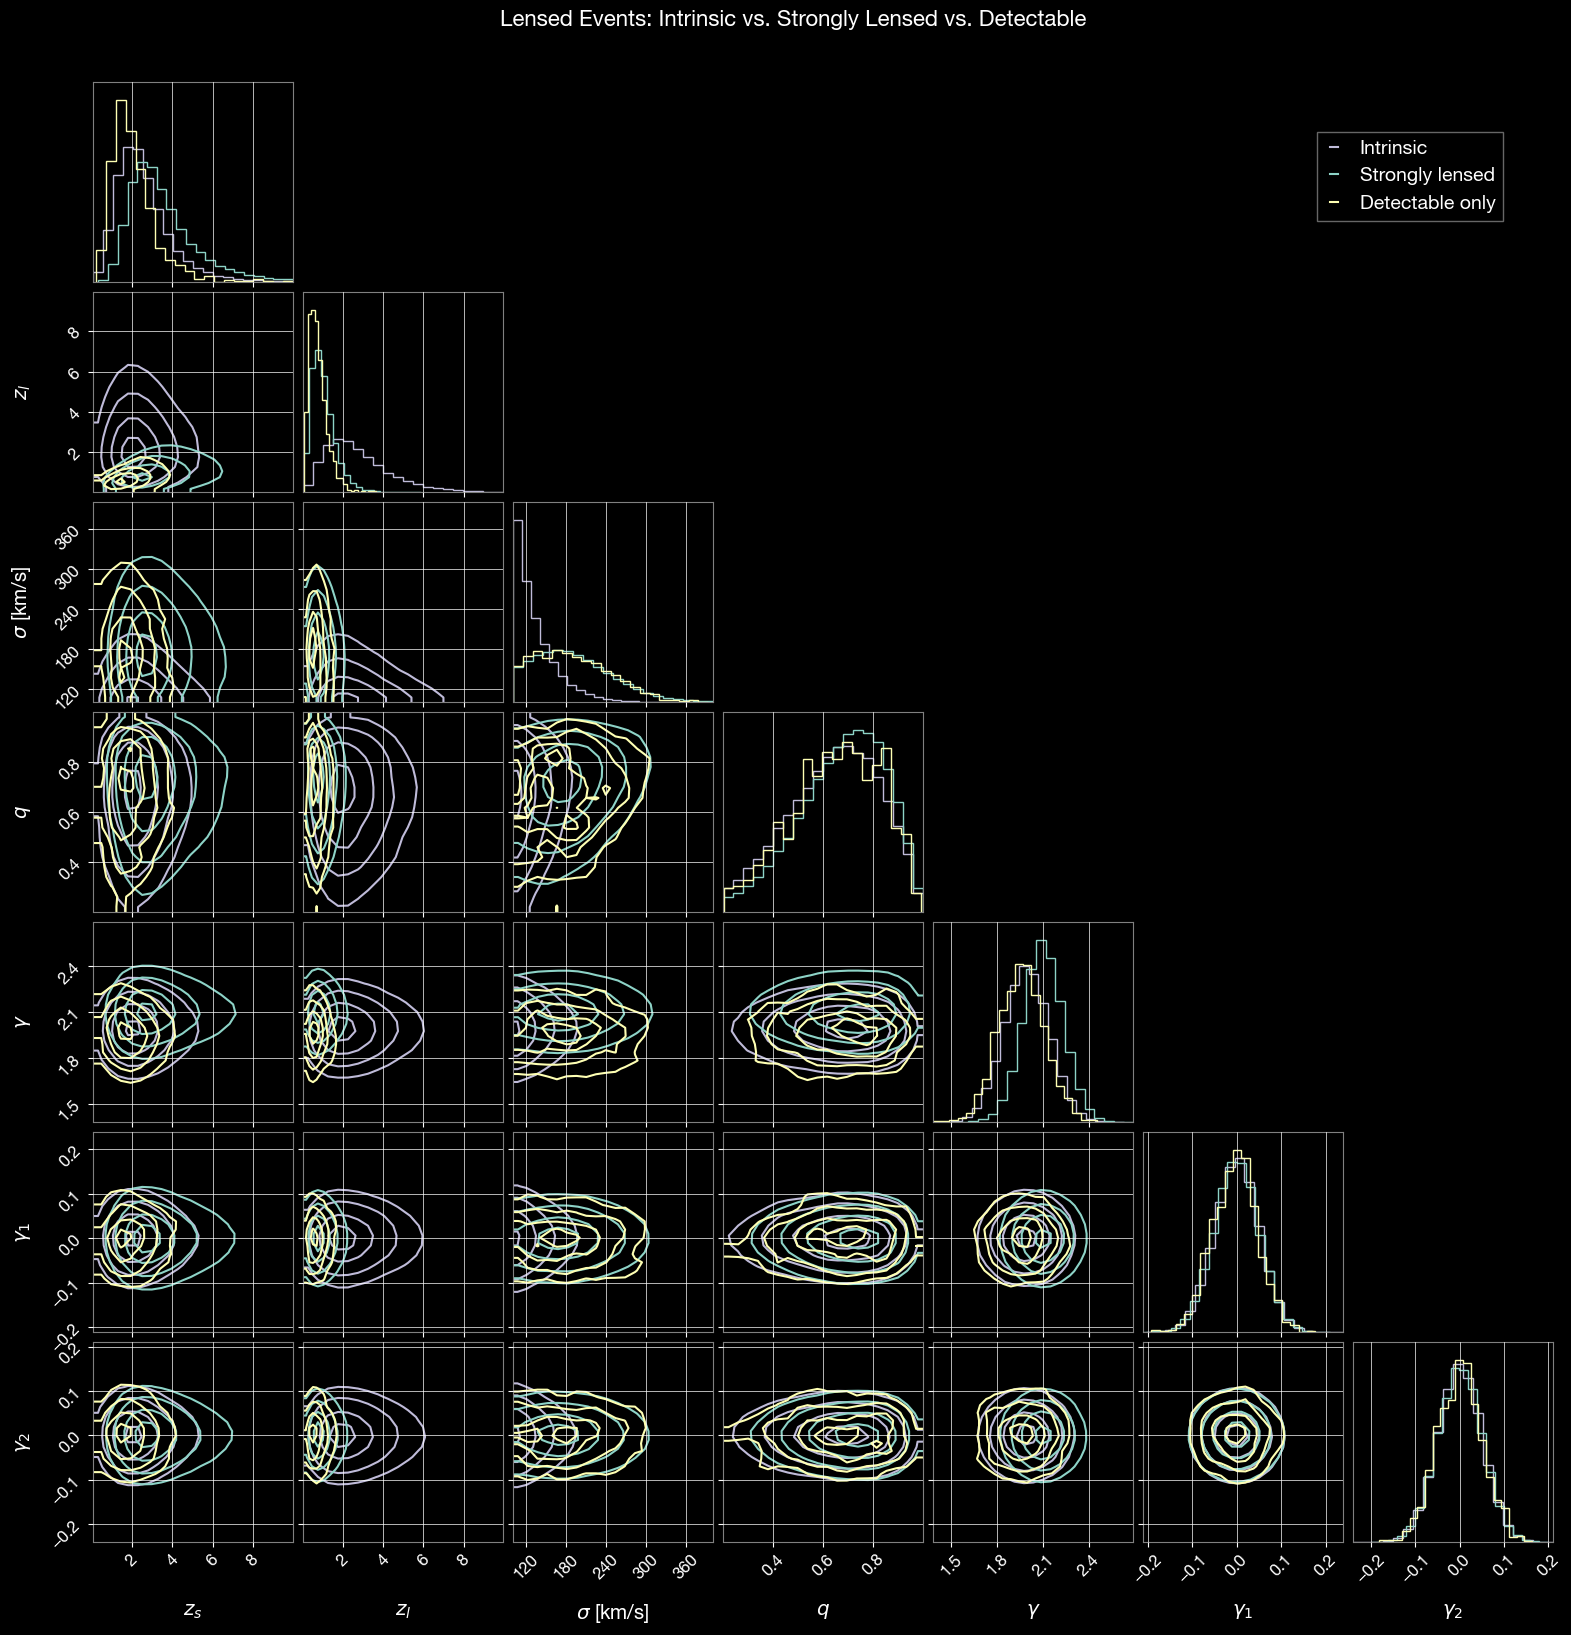

In [12]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from ler.utils import get_param_from_json

# Load data
param = get_param_from_json('./ler_data/lensed_params_all.json')
param_detectable = get_param_from_json('./ler_data/lensed_params_n_detectable.json')
param_intrinsic = get_param_from_json('./ler_data/lensed_param_intrinsic.json')
# lensed_param_intrinsic is already in memory from cell 24

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'q', 'gamma', 'gamma1', 'gamma2']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$', r'$\gamma$', r'$\gamma_1$', r'$\gamma_2$']

# Prepare data for corner plot
samples_intrinsic = np.stack([param_intrinsic[p] for p in param_names], axis=1)
samples_all = np.stack([param[p] for p in param_names], axis=1)
samples_detectable = np.stack([param_detectable[p] for p in param_names], axis=1)

# Create corner plot for intrinsic events
fig = corner.corner(
    samples_intrinsic, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay strongly lensed events
corner.corner(
    samples_all, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay detectable events
corner.corner(
    samples_detectable, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig, 
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add legend
green_line = mlines.Line2D([], [], color='C2', label='Intrinsic')
blue_line = mlines.Line2D([], [], color='C0', label='Strongly lensed')
orange_line = mlines.Line2D([], [], color='C1', label='Detectable only')
fig.legend(handles=[green_line, blue_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
fig.suptitle('Lensed Events: Intrinsic vs. Strongly Lensed vs. Detectable', fontsize=16, y=1.02)

plt.show()

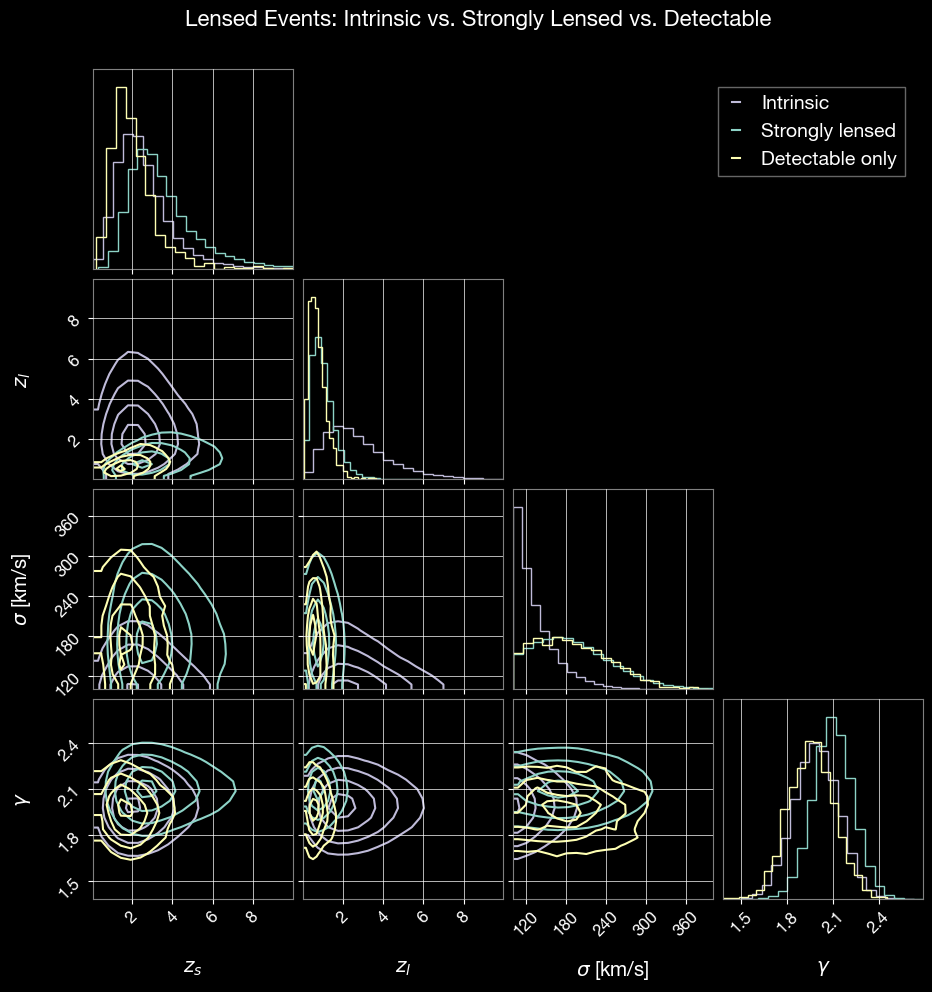

In [13]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from ler.utils import get_param_from_json

# Load data
param = get_param_from_json('./ler_data/lensed_params_all.json')
param_detectable = get_param_from_json('./ler_data/lensed_params_n_detectable.json')
param_intrinsic = get_param_from_json('./ler_data/lensed_param_intrinsic.json')
# lensed_param_intrinsic is already in memory from cell 24

# Lensing-specific parameters to compare
param_names = ['zs', 'zl', 'sigma', 'gamma']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', r'$\gamma$']

# Prepare data for corner plot
samples_intrinsic = np.stack([param_intrinsic[p] for p in param_names], axis=1)
samples_all = np.stack([param[p] for p in param_names], axis=1)
samples_detectable = np.stack([param_detectable[p] for p in param_names], axis=1)

# Create corner plot for intrinsic events
fig = corner.corner(
    samples_intrinsic, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay strongly lensed events
corner.corner(
    samples_all, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Overlay detectable events
corner.corner(
    samples_detectable, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig, 
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add legend
green_line = mlines.Line2D([], [], color='C2', label='Intrinsic')
blue_line = mlines.Line2D([], [], color='C0', label='Strongly lensed')
orange_line = mlines.Line2D([], [], color='C1', label='Detectable only')
fig.legend(handles=[green_line, blue_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
fig.suptitle('Lensed Events: Intrinsic vs. Strongly Lensed vs. Detectable', fontsize=16, y=1.02)

plt.show()

---

## 4. Visualizing Lensed Detectable Events

Visualize properties of detectable lensed events. An example event is highlighted in each plot to show individual characteristics within the population.

### 4.1 Redshift Distribution

Compare redshift distributions of intrinsic and detected populations.

Chosen detected lensed event index: 14


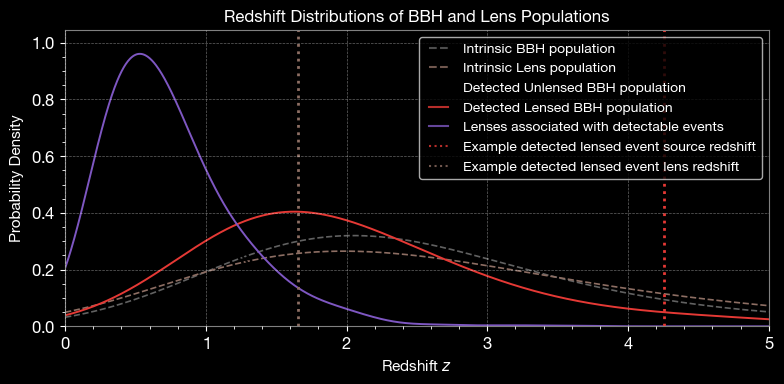

In [14]:
from ler.utils import get_param_from_json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

np.random.seed(100)

# Load data
unlensed_params_det = get_param_from_json('./ler_data/unlensed_params_n_detectable.json')
lensed_params_det = get_param_from_json('./ler_data/lensed_params_n_detectable.json')
unlensed_params = get_param_from_json('./ler_data/unlensed_params_all.json')
lensed_params = get_param_from_json('./ler_data/lensed_params_all.json')
lensed_params_intrinsic = get_param_from_json('./ler_data/lensed_param_intrinsic.json')

bbh_pop_intrinsic = unlensed_params['zs']
unlensed_bbh_pop_detected = unlensed_params_det['zs']
lensed_bbh_pop_detected = lensed_params_det['zs']
lens_detected = lensed_params_det['zl']
lens_dist_intrinsic = lensed_params_intrinsic['zl']

# create gaussian kde
from scipy.stats import gaussian_kde
bandwidth = 0.4
kde_bbh_pop_intrinsic = gaussian_kde(bbh_pop_intrinsic, bw_method=bandwidth)
kde_unlensed_bbh_pop_detected = gaussian_kde(unlensed_bbh_pop_detected, bw_method=bandwidth)
kde_lensed_bbh_pop_detected = gaussian_kde(lensed_bbh_pop_detected, bw_method=bandwidth)
kde_lens_dist_intrinsic = gaussian_kde(lens_dist_intrinsic, bw_method=bandwidth)
kde_lens_detected = gaussian_kde(lens_detected, bw_method=bandwidth)

# Choose a random detected lensed event to highlight
pdet = lensed_params_det['pdet_net']
idx_4img = pdet > 0.5
idx_4img = np.sum(idx_4img, axis=1) ==2 # 2 images detected
chosen_idx_list = np.where(idx_4img)[0]
chosen_idx = chosen_idx_list[10]  # pick the 10th one for consistency
print(f"Chosen detected lensed event index: {chosen_idx}")

# ---------- Data ----------
z = np.linspace(0, 5, 1000)

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 4))

colors = {
    "black": "#000000",
    "violet": "#7E57C2",
    "brown": "#8D6E63",
    "grey": "#616161",
    "red": "#E53935",
    "blue": "#1E88E5",
}

# intrinsic distributions
ax.plot(z, kde_bbh_pop_intrinsic(z), label='Intrinsic BBH population',
        color=colors["grey"], linestyle='--', linewidth=1.2)
ax.plot(z, kde_lens_dist_intrinsic(z), label='Intrinsic Lens population',
        color=colors["brown"], linestyle='--', linewidth=1.2)

# detected distributions
ax.plot(z, kde_unlensed_bbh_pop_detected(z), label='Detected Unlensed BBH population',
        color=colors["black"], linestyle='-', linewidth=1.4)
ax.plot(z, kde_lensed_bbh_pop_detected(z), label='Detected Lensed BBH population',
        color=colors["red"], linestyle='-', linewidth=1.4)
ax.plot(z, kde_lens_detected(z), label='Lenses associated with detectable events',
        color=colors["violet"], linestyle='-', linewidth=1.4)

# Example detected lensed event redshifts
ax.axvline(lensed_params_det['zs'][chosen_idx],
           color=colors["red"], linestyle=':', linewidth=2,
           label='Example detected lensed event source redshift')
ax.axvline(lensed_params_det['zl'][chosen_idx],
           color=colors["brown"], linestyle=':', linewidth=2,
           label='Example detected lensed event lens redshift')

# ---------- Legend ----------
legend = ax.legend(
    handlelength=2.0,
    loc='upper right',
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=10.,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.5)
    handle.set_alpha(0.8)

# ---------- Axes labels, limits, and grid ----------
ax.set_xlabel(r'Redshift $z$', fontsize=11)
ax.set_ylabel(r'Probability Density', fontsize=11)
ax.set_xlim(0, 5)
ax.set_ylim(0, None)

ax.grid(alpha=0.4, linestyle='--', linewidth=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# add title
ax.set_title('Redshift Distributions of BBH and Lens Populations', fontsize=12)

plt.tight_layout()
# plt.savefig('lens_paramters_baseline_redshift_distributions.svg',
#             dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### 4.2 Magnification Ratio vs Time Delay 

Relative magnification vs time delay distinguishes lensed from unlensed events.

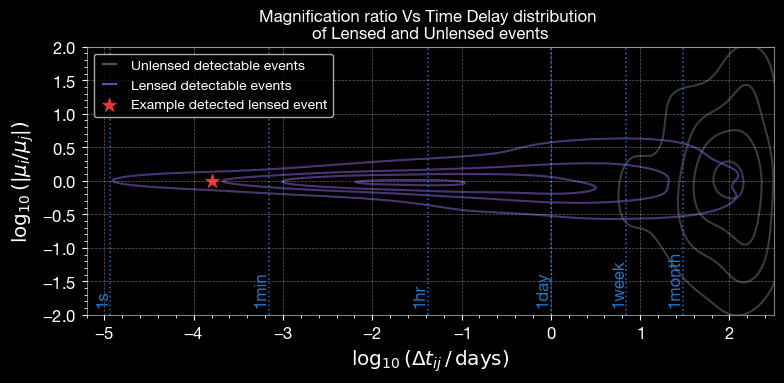

In [34]:
from ler.utils import relative_mu_dt_unlensed, relative_mu_dt_lensed, mu_vs_dt_plot

# for unlensed detectable events
dmu_unlensed, dt_unlensed = relative_mu_dt_unlensed(param=unlensed_params_det)

# for lensed detectable events
lensed_dict = relative_mu_dt_lensed(lensed_param=lensed_params_det)
dt_lensed = np.concatenate((lensed_dict['dt_rel0'], lensed_dict['dt_rel90']))
dmu_lensed = np.concatenate((lensed_dict['mu_rel0'], lensed_dict['mu_rel90']))

# chosen example index for 4 images, find time delays and magnifications
chosen_lens_dt = lensed_params_det['time_delays'][chosen_idx]
chosen_lens_mu = lensed_params_det['magnifications'][chosen_idx]
pdet = lensed_params_det['pdet_net'][chosen_idx]

dt_lensed_chosen = np.log10((chosen_lens_dt[2]-chosen_lens_dt[1])/ (60 * 60 * 24))
dmu_lensed_chosen = np.log10(abs(chosen_lens_mu[2]/chosen_lens_mu[1]))

# ---------------------------------------
# Plot Magnification ratio Vs Time Delay
# ---------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

colors = {
    "black": "#000000",
    "violet": "#7E57C2",
    "brown": "#8D6E63",
    "grey": "#616161",
    "red": "#E53935",
    "blue": "#1E88E5",
}

# Use your existing helper without modification
mu_vs_dt_plot(dt_unlensed, dmu_unlensed, colors=[colors['grey']]*5)
mu_vs_dt_plot(dt_lensed,   dmu_lensed,   colors=[colors['violet']]*5)

# Proxy artists for legend
# Proxy artists for legend
ax.plot([], [], color=colors['grey'],  linestyle='-', label='Unlensed detectable events', linewidth=1.5)
ax.plot([], [], color=colors['violet'], linestyle='-', label='Lensed detectable events',   linewidth=1.5)

# Chosen example point
ax.scatter(
    dt_lensed_chosen, dmu_lensed_chosen,
    color=colors['red'], marker='*', s=110, linewidths=0.6,
    label='Example detected lensed event'
)

# plot line for 1s, 1hr, 1day, 1week, 1month time delays
time_delays = [1, 60, 60*60, 60*60*24, 60*60*24*7, 60*60*24*30]
labels_td = ['1s', '1min', '1hr', '1day', '1week', '1month']
for td in time_delays:
    ax.axvline(np.log10(td/(60*60*24)), color=colors['blue'], linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(np.log10(td/(60*60*24)), ax.get_ylim()[1]*-0.7, labels_td[time_delays.index(td)], color=colors['blue'], fontsize=12, rotation=90, va='bottom', ha='right', alpha=0.9)

# ---------- Legend ----------
legend = ax.legend(
    handlelength=1.5,
    loc='upper left',
    bbox_to_anchor=(0, 1),
    frameon=True,
    fontsize=10,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.6)
    handle.set_alpha(0.85)

# add title
ax.set_title('Magnification ratio Vs Time Delay distribution \nof Lensed and Unlensed events', fontsize=12)

# ---------- Axes, ticks, grid ----------
ax.set_xlabel(r'$\log_{10}(\Delta t_{ij} \,/\, \mathrm{days})$')
ax.set_ylabel(r'$\log_{10}(|\mu_i / \mu_j|)$')
ax.set_xlim(-5.2, 2.5)
ax.set_ylim(-2, 2)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(alpha=0.38, linestyle='--', linewidth=0.5)

plt.tight_layout()
# plt.savefig('mu_vs_dt_science_ieee.svg', dpi=600, bbox_inches='tight', transparent=True)
plt.show()
# time: 32s

### 4.3 Caustic Plot

Lens configuration for an example event, showing caustics, critical curves, and image positions.

In [27]:
# include other useful parameters in the output dictionary.
# It is omitted by default to save runtime and memory.
# For theta_E, n_images, mass_1, mass_2, luminosity_distance:
lensed_params_det = ler.recover_redundant_parameters(lensed_params_det)

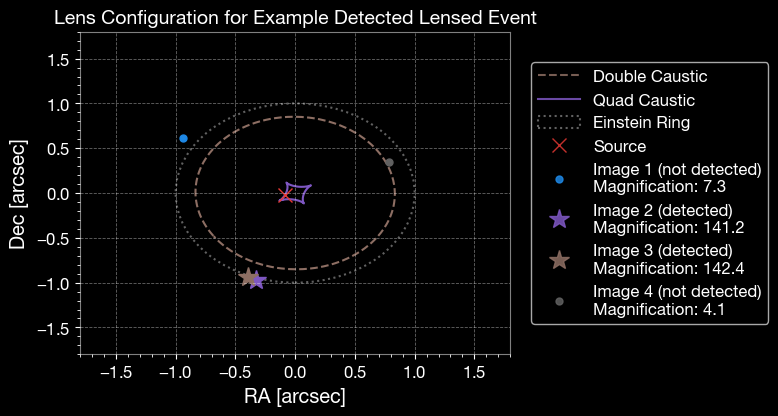

In [32]:
from ler.image_properties.cross_section_njit import caustic_points_epl_shear
from ler.image_properties.epl_shear_njit import image_position_analytical_njit

# ---------- Custom color palette ----------
colors = {
    "black": "#000000",
    "violet": "#7E57C2",
    "brown":  "#8D6E63",
    "grey":   "#616161",
    "red":    "#E53935",
    "blue":   "#1E88E5",
    "green":  "#43A047",
    "orange": "#FB8C00",
}

# ----- Lens parameters -----
q   = lensed_params_det['q'][chosen_idx]
phi = lensed_params_det['phi'][chosen_idx]
gamma = lensed_params_det['gamma'][chosen_idx]
gamma1 = lensed_params_det['gamma1'][chosen_idx]
gamma2 = lensed_params_det['gamma2'][chosen_idx]
theta_E = lensed_params_det['theta_E'][chosen_idx]

# ----- Solve image configuration -----
# unscaled source position
beta_ra  = lensed_params_det['x_source'][chosen_idx] / theta_E
beta_dec = lensed_params_det['y_source'][chosen_idx] / theta_E

x_img, y_img, fermat_pot, mu, image_type, nimg = image_position_analytical_njit(
    beta_ra, beta_dec, q, phi, gamma, gamma1, gamma2,
    theta_E=1.0, magnification_limit=1.0/100.0,
)
theta_ra = x_img[:nimg]
theta_dec = y_img[:nimg]
magnifications = np.abs(mu[:nimg])

# ----- Figure -----
fig, ax = plt.subplots(figsize=(8, 7))  # wider figure

# Caustics
cp = caustic_points_epl_shear(1.0, q, phi, gamma, gamma1, gamma2, num_th=500, maginf=-100.0, quad=False)
ax.plot(cp[0], cp[1], color=colors['brown'], linewidth=1.5, linestyle='--', label='Double Caustic')
cp = caustic_points_epl_shear(1.0, q, phi, gamma, gamma1, gamma2, num_th=500, maginf=-100.0, quad=True)
ax.plot(cp[0], cp[1], color=colors['violet'], linewidth=1.5, linestyle='-', label='Quad Caustic')

# Einstein ring
circle = plt.Circle((0, 0), 1.0, color=colors['grey'], fill=False,
                    linestyle='dotted', linewidth=1.5, label='Einstein Ring')
ax.add_artist(circle)

# Source position
ax.plot(beta_ra, beta_dec, marker='x', ls='None', color=colors['red'], label='Source', markersize=10)

# Image positions
img_colors = [colors['blue'], colors['violet'], colors['brown'], colors['grey']]
pdet_image = lensed_params_det['pdet_net'][chosen_idx]
for i in range(nimg):
    if pdet_image[i] >= 0.5:
        ax.plot(theta_ra[i], theta_dec[i], marker='*', ls='None',
                color=img_colors[i % len(img_colors)],
                label=f'Image {i+1} (detected)\nMagnification: {magnifications[i]:.1f}', markersize=15)
    else:
        ax.plot(theta_ra[i], theta_dec[i], marker='.', ls='None',
                color=img_colors[i % len(img_colors)],
                label=f'Image {i+1} (not detected)\nMagnification: {magnifications[i]:.1f}', markersize=10)
# Axes & Grid
ax.set_xlabel('RA [arcsec]')
ax.set_ylabel('Dec [arcsec]')
dim_x, dim_y = 1.8, 1.8  # rectangular window
ax.set_xlim(-dim_x, dim_x)
ax.set_ylim(-dim_y, dim_y)

# Relax the aspect ratio → visually rectangular (with adjustable='box' to respect figure size)
ax.set_aspect(6/8, adjustable='box')

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(alpha=0.4, linestyle='--', linewidth=0.6)

# Legend on the side
legend = ax.legend(
    handlelength=2.5,
    loc='center left',
    bbox_to_anchor=(1.03, 0.5),
    frameon=True,
    fontsize=12,
    edgecolor='lightgray',
    numpoints=1,  # Show only one marker per legend entry
    scatterpoints=1
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.5)
    handle.set_alpha(0.85)
# add title
ax.set_title('Lens Configuration for Example Detected Lensed Event', fontsize=14)
plt.tight_layout()
# plt.savefig('lens_configuration_rectangular.svg', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

* If you want to use lenstronomy to solve the lens configuration and plot the lensing caustics, critical curves, and image positions, you can use the following code snippet:

In [ ]:
# from lenstronomy.LensModel.lens_model import LensModel
# from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# from lenstronomy.LensModel.Solver.epl_shear_solver import caustics_epl_shear
# # import phi_q2_ellipticity
# from lenstronomy.Util.param_util import phi_q2_ellipticity

# # ---------- Custom color palette ----------
# colors = {
#     "black": "#000000",
#     "violet": "#7E57C2",
#     "brown":  "#8D6E63",
#     "grey":   "#616161",
#     "red":    "#E53935",
#     "blue":   "#1E88E5",
#     "green":  "#43A047",
#     "orange": "#FB8C00",
# }

# # ----- Lens setup -----
# lens_model_list = ["EPL", "SHEAR"]
# lensModel = LensModel(lens_model_list=lens_model_list)
# lens_eq_solver = LensEquationSolver(lensModel)

# q   = lensed_params_det['q'][chosen_idx]
# phi = lensed_params_det['phi'][chosen_idx]
# e1, e2 = phi_q2_ellipticity(phi, q)
# kwargs_spep = {
#     'theta_E': 1.0,
#     'e1': e1,
#     'e2': e2,
#     'gamma': lensed_params_det['gamma'][chosen_idx],
#     'center_x': 0.0,
#     'center_y': 0.0,
# }
# kwargs_shear = {
#     'gamma1': lensed_params_det['gamma1'][chosen_idx],
#     'gamma2': lensed_params_det['gamma2'][chosen_idx]
# }
# kwargs_lens = [kwargs_spep, kwargs_shear]

# # ----- Solve image configuration -----
# theta_E = lensed_params_det['theta_E'][chosen_idx]
# # unscaled source position
# beta_ra  = lensed_params_det['x_source'][chosen_idx]/theta_E
# beta_dec = lensed_params_det['y_source'][chosen_idx]/theta_E
# theta_ra, theta_dec = lens_eq_solver.image_position_from_source(
#     sourcePos_x=beta_ra, sourcePos_y=beta_dec, kwargs_lens=kwargs_lens,
#     solver="analytical", magnification_limit=1.0/100.0, arrival_time_sort=True
# )
# magnifications = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)
# magnifications = np.abs(np.array(magnifications))
# # print(f"Magnifications calculated: {magnifications}")

# # ----- Figure -----
# fig, ax = plt.subplots(figsize=(8, 7))  # wider figure

# # Caustics
# cp = caustics_epl_shear(kwargs_lens, return_which="double", maginf=-100)
# ax.plot(cp[0], cp[1], color=colors['brown'], linewidth=1.5, linestyle='--', label='Double Caustic')
# cp = caustics_epl_shear(kwargs_lens, return_which="quad", maginf=-100)
# ax.plot(cp[0], cp[1], color=colors['violet'], linewidth=1.5, linestyle='-', label='Quad Caustic')

# # Einstein ring
# theta_E = 1.0
# circle = plt.Circle((0, 0), theta_E, color=colors['grey'], fill=False,
#                     linestyle='dotted', linewidth=1.5, label='Einstein Ring')
# ax.add_artist(circle)

# # Source position
# ax.plot(beta_ra, beta_dec, marker='x', ls='None', color=colors['red'], label='Source', markersize=10)

# # Image positions
# img_colors = [colors['blue'], colors['violet'], colors['brown'], colors['black']]
# pdet_image = lensed_params_det['pdet_net'][chosen_idx]
# for i in range(len(theta_ra)):
#     if pdet_image[i] >= 0.5:
#         ax.plot(theta_ra[i], theta_dec[i], marker='*', ls='None',
#                 color=img_colors[i % len(img_colors)],
#                 label=f'Image {i+1} (detected)\nMagnification: {magnifications[i]:.1f}', markersize=15)
#     else:
#         ax.plot(theta_ra[i], theta_dec[i], marker='.', ls='None',
#                 color=img_colors[i % len(img_colors)],
#                 label=f'Image {i+1} (not detected)\nMagnification: {magnifications[i]:.1f}', markersize=10)
# # Axes & Grid
# ax.set_xlabel('RA [arcsec]')
# ax.set_ylabel('Dec [arcsec]')
# dim_x, dim_y = 1.8, 1.8  # rectangular window
# ax.set_xlim(-dim_x, dim_x)
# ax.set_ylim(-dim_y, dim_y)

# # Relax the aspect ratio → visually rectangular (with adjustable='box' to respect figure size)
# ax.set_aspect(6/8, adjustable='box')

# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.grid(alpha=0.4, linestyle='--', linewidth=0.6)

# # Legend on the side
# legend = ax.legend(
#     handlelength=2.5,
#     loc='center left',
#     bbox_to_anchor=(1.03, 0.5),
#     frameon=True,
#     fontsize=12,
#     edgecolor='lightgray',
#     numpoints=1,  # Show only one marker per legend entry
#     scatterpoints=1
# )
# legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
# for handle in legend.get_lines():
#     handle.set_linewidth(1.5)
#     handle.set_alpha(0.85)
# # add title
# ax.set_title('Lens Configuration for Example Detected Lensed Event', fontsize=14)
# plt.tight_layout()
# # plt.savefig('lens_configuration_rectangular.svg', dpi=600, bbox_inches='tight', transparent=True)
# plt.show()

---

## 5. Summary

This notebook demonstrated advanced sampling capabilities of **LeR** for generating detectable GW events.

**Key Takeaways:**

1. **N-Event Sampling:** `selecting_n_unlensed_detectable_events` and `selecting_n_lensed_detectable_events` collect a target number of detectable events with convergence monitoring.

2. **Rate Convergence:** Tracking rates across batches verifies statistical stability.

3. **Resume Capability:** Sampling can be interrupted and resumed without losing progress.

4. **Selection Effects**: The corner plots reveal how detector sensitivity and strong lensing selection bias the observed populations:
   - **Detector sensitivity effects:**
     - Lower redshift events are preferentially detected
     - Higher mass events have higher detection probability
     - Sky location and orientation effects are visible
   - **Strong lensing selection effects:**
     - Higher magnification events are more likely to be detected
     - Lensed events tend to occur at higher redshifts
     - Lens velocity dispersion influences strong lensing due to increased lensing cross-section
     - Lens galaxy density profile slope affects detectability

5. **Lensing Visualization**: The redshift distributions, magnification-time delay plots, and caustic diagrams provide insight into the properties of detectable lensed events.
